In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import time
import sys
import pandas as pd
import importlib
sys.path.append('..')
import plot_settings
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import torch
import Ue_GP

colors = plot_settings.colors()

sys.path.append('nodes_2')
import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib
def import_reload():
    plot_settings.apply()
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

import warnings
warnings.filterwarnings("ignore", message=".*__array_wrap__.*")

# Importing data

In [2]:
DT = 1
Q0 = 17921.57581 
#(data['I'][data['trajectory'] == 10].values)[0]  * 3600 / (data['C'][data['trajectory'] == 10].values)[0]  
#print(f'Q0: {Q0:.5f} As')

In [3]:
def read_raw_data(file_name, pulse=False):

    if pulse:
        df = pd.read_csv(
        f"Multi_data/raw_pulse/{file_name}.txt",
        sep=r'\s+',
        comment="%",
        header=None
    )
        df.columns = ['u_par','C','t','V','I_dummy','F','u','Ue','soc','I']
    else:
        df = pd.read_csv(
        f"Multi_data/raw_DC/{file_name}.txt",
        sep=r'\s+',
        comment="%",
        header=None
    )
        df.columns = ['u_par', 'C', 't', 'V', 'I', 'F', 'u', 'Ue','soc','I_dummy']
    return df

def read_data(file_name):
    df = pd.read_csv(
        f"Multi_data/{file_name}.txt",
        sep=';',
        comment="%"
    )
    return df

def group_trajectories(df):
    """
    Group trajectories by unique combinations of 'C' and 'u_par'.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe with columns 'C' and 'u_par'.

    Returns
    -------
    pd.DataFrame
        DataFrame with an added 'trajectory' column indicating group membership.
    """
    df['trajectory'] = df.groupby(['C', 'u_par'], sort=False).ngroup()
    return df

def scaling(df, charge = False):

    '''
    Rescales: 
        Displacement: from m to 10*µm
        Force:        from N to GN
    '''

    df['u'] = df['u'] * 1e5
    df['F'] = df['F'] * 1e-9
    df['eta'] = df['Ue'] - df['V']
    if charge:
        df['eta'] = - df['eta'] 
    return df

def preprocess_data(file_name,Pulse = True):
    df = group_trajectories(read_raw_data(file_name,pulse = Pulse))
    df = scaling(df)
    return df
    
def save_data(df, file_name_mod,pølse=False):
    df = df.drop(columns=['I_dummy'])
    if pølse:
        df.to_csv(f'Multi_data/polished_pulses/{file_name_mod}.txt', index=False, sep=';')
    elif pølse == None:
        df.to_csv(f'Multi_data/{file_name_mod}.txt', index=False, sep=';')
    elif pølse == False:
        df.to_csv(f'Multi_data/polished_DC/{file_name_mod}.txt', index=False, sep=';')
    

In [4]:
path_pulse = f'full_cycles'

data = preprocess_data(path_pulse, Pulse = True)

save_data(data, 'cycles', pølse=None)


#data_test = read_data('crate2.5_usweep_pulse')
#plt.plot(data_test['t'], data_test['I'], label='V')

#data = read_data('polished_DC/merged_DC_hyper')

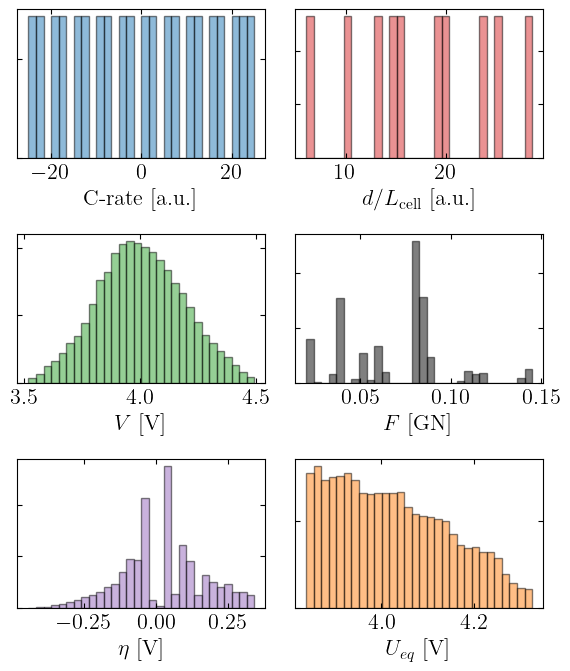

In [5]:
f, ax = plt.subplots(3,2,figsize=(6, 7))
ax[0,0].hist(np.unique(data['I']), bins=30, color=colors[0], alpha=0.5,edgecolor='black',density=True)
ax[0,1].hist(np.unique(data['u_par']), bins=30, color=colors[1], alpha=0.5,edgecolor='black',density=True)
ax[1,0].hist(data['V'], bins=30, color=colors[2], alpha=0.5,edgecolor='black',density=True)
ax[1,1].hist(np.unique(data['F']), bins=30, color=colors[3], alpha=0.5,edgecolor='black',density=True)
ax[2,1].hist(data['Ue'], bins=30, color=colors[4], alpha=0.5,edgecolor='black',density=True)
ax[2,0].hist((data['eta']), bins=30, color=colors[5], alpha=0.5,edgecolor='black',density=True)
ax[0,0].set_xlabel('C-rate [a.u.]')
ax[0,1].set_xlabel(r'$d/L_{\mathrm{cell}}$ [a.u.]')
ax[1,0].set_xlabel('$V$ [V]')
ax[1,1].set_xlabel('$F$ [GN]')
ax[2,1].set_xlabel('$U_{eq}$ [V]')
ax[2,0].set_xlabel(r'$\eta$ [V]')
#ax[2,0].set_xlabel('$E_{Ue}$')
#ax[2,1].set_xlabel('$d$')
for a in ax.flat:
    a.set_yticklabels([])
plt.tight_layout()
plt.show()

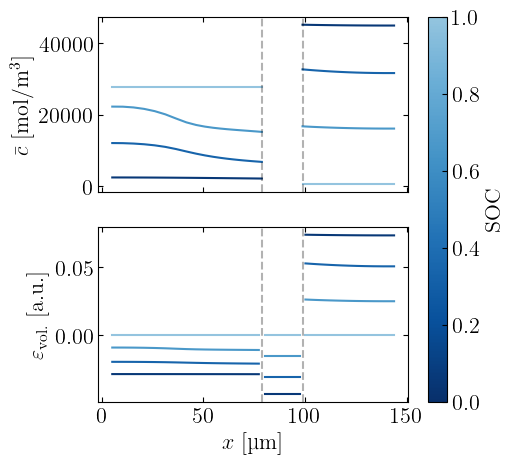

In [6]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
Ln = 7.8733*10; Ls = 20
df_conc = pd.read_csv('Multi_data/concentration_strain_2.csv', comment="%")

base = plt.cm.Blues_r
cmap = LinearSegmentedColormap.from_list(
    "Blues_custom", base(np.linspace(0.0, 0.6, 256)))

df_conc.columns = ['x', 'c_0', 'e0','soc_0','c_1', 'e1','soc_1','c_2', 'e2','soc_2', 'c_3', 'e3','soc_3']
f,ax = plt.subplots(2,1,figsize=(5, 5), sharex=True)
for i in range(4):
    ax[0].plot(df_conc['x'] * 1e6, df_conc[f'c_{i}'], label=f'c_{i}', color=cmap(df_conc[f'soc_{i}'].iloc[0]))
    inds = [df_conc['x'] * 1e6 < Ln -0.1, (df_conc['x'] * 1e6 > Ln) & (df_conc['x'] * 1e6 < Ln + Ls-0.1), df_conc['x'] * 1e6 > Ln + Ls+0.1]
    for j in inds:
        ax[1].plot(df_conc['x'].values[j] * 1e6, df_conc[f'e{i}'].values[j], label=f'e_{i}', color=cmap(df_conc[f'soc_{i}'].iloc[0]))
plt.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=cmap), ax=ax, label='SOC')
ax[0].axvline(Ln, color='black', linestyle='--', alpha = 0.3)
ax[0].axvline(Ln + Ls, color='black', linestyle='--', alpha = 0.3)

ax[1].axvline(Ln, color='black', linestyle='--', alpha = 0.3)
ax[1].axvline(Ln + Ls, color='black', linestyle='--', alpha = 0.3)
ax[0].set_ylabel(r'$\bar{c}$ [mol/m$^3$]')
ax[1].set_xlabel('$x$ [µm]')
ax[1].set_ylabel(r'$\varepsilon_{\mathrm{vol.}}$ [a.u.]')
plt.savefig('Multi_data/concentration_strain_2.pdf', bbox_inches='tight')

To deal with more reasonable values, $F$ is measured in GN, while $\Delta u$ is measured in $10^{-5}$ m

In [7]:
# def merge_runs(n_runs, pulse = False, add_run_id=False):
#     """
#     Merge multiple run files into one dataframe.

#     Parameters
#     ----------
#     run_names : list[str]
#         Run names without extension, e.g. ['1_run', '2_run'].
#     base_dir : str
#         Folder containing the .txt run files.
#     add_run_id : bool
#         If True, adds a 'run_id' column.

#     Returns
#     -------
#     pd.DataFrame
#         Merged and preprocessed dataframe.
#     """
#     if pulse:
#         base_dir = "Multi_data/raw_pulses"
#     else:
#         base_dir = "Multi_data/raw_DC"
    
#     run_names = []
#     for n in range(1, n_runs+1):
#         if pulse:
#             run_names.append(f"data_pulse_hyper_{n}")
#         else:
#             run_names.append(f"data_CC_hyper_{n}")

#     print(f"Merging runs: {run_names}")

#     frames = []
#     for run in run_names:
#         df = preprocess_data(f"{run}", Pulse=pulse)

#         frames.append(df)

#     merged = pd.concat(frames, ignore_index=True)
#     # remove duplicates in C and u_par if they exist
#     merged = merged.drop_duplicates(subset=['C', 'u_par', 't'])

#     # optional global trajectory labeling across merged runs
#     merged['trajectory'] = merged.groupby(['C', 'u_par'], sort=False).ngroup()

#     return merged

# df_merged = merge_runs(3, pulse=True, add_run_id=True)
# print(df_merged['trajectory'].nunique())



def merge_runs(
    n_runs,
    pulse=None,
    add_run_id=False,
    shuffle_trajectories=False,
    random_state=None
):
    """
    Merge multiple run files into one dataframe.
    """

    import numpy as np
    import pandas as pd

    run_configs = []

    # Add pulse runs
    if pulse is True or pulse is None:
        for n in range(1, n_runs + 1):
            run_configs.append({
                "name": f"data_pulse_hyper_{n}",
                "pulse": True
            })

    # Add DC/non-pulse runs
    if pulse is False or pulse is None:
        for n in range(1, n_runs + 1):
            run_configs.append({
                "name": f"data_CC_hyper_{n}",
                "pulse": False
            })

    print("Merging runs:")
    for cfg in run_configs:
        print(f"  {cfg['name']} (pulse={cfg['pulse']})")

    frames = []

    for cfg in run_configs:

        df = preprocess_data(cfg["name"], Pulse=cfg["pulse"])

        if add_run_id:
            df["run_id"] = cfg["name"]

        df["pulse"] = cfg["pulse"]

        frames.append(df)

    merged = pd.concat(frames, ignore_index=True)

    # Remove duplicates
    merged = merged.drop_duplicates(subset=['C', 'u_par', 't'])

    # Initial trajectory labels
    merged['trajectory'] = (
        merged.groupby(['C', 'u_par'], sort=False).ngroup()
    )

    # ---------------------------------------------------
    # Shuffle whole trajectories
    # ---------------------------------------------------
    if shuffle_trajectories:

        rng = np.random.default_rng(random_state)

        # Unique trajectory IDs
        traj_ids = merged['trajectory'].unique()

        # Shuffle trajectory order
        shuffled_ids = rng.permutation(traj_ids)

        shuffled_frames = []

        for traj_id in shuffled_ids:

            traj_df = merged[merged['trajectory'] == traj_id]

            # Keep time ordering inside trajectory
            traj_df = traj_df.sort_values('t')

            shuffled_frames.append(traj_df)

        merged = pd.concat(shuffled_frames, ignore_index=True)

        # -----------------------------------------------
        # Recreate trajectory IDs AFTER shuffling
        # so they become ordered 0,1,2,3,...
        # in the shuffled order
        # -----------------------------------------------
        merged = merged.drop(columns=['trajectory'])

        merged['trajectory'] = (
            merged.groupby(['C', 'u_par'], sort=False).ngroup()
        )

 
    return merged




combo_half = read_data('combo_half')

combo_high = combo_half[combo_half['C']>=2]
combo_low1 = combo_half[combo_half['C'] == 0.61]
combo_low2 = combo_half[combo_half['C'] == 1]

combo_high.describe()

combo_high.to_csv(f'Multi_data/combo_high.txt', index=False, sep=';')

#df_shrinked = df[(df['u_par']>=20) & ((df['C']>=3.5))]
#df_shrinked = df[(df['trajectory'] % 2 == 1)]  # Keep only even trajectory IDs as an example of shrinking
#print(df_shrinked['trajectory'].nunique())
#save_data(df_shrinked, 'combo_other_half', pulse=pulse)
#df_shrinked.describe()

## DATA EXPLORATION

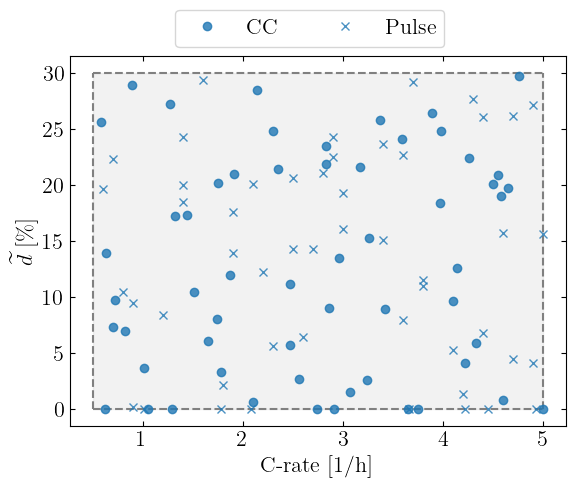

In [20]:
data = combo_half
df_CC = data[data['pulse'] == False]
df_pulse = data[data['pulse'] == True]

plt.xlabel('C-rate [1/h]')
plt.ylabel(r'$\widetilde{d}$ [\%]')
plt.vlines(0.5,0,30, color='gray', linestyle='--')
plt.vlines(5,0,30, color='gray', linestyle='--')
plt.hlines(0,0.5,5, color='gray', linestyle='--')
plt.hlines(30,0.5,5, color='gray', linestyle='--')
plt.fill_between([0.5, 5], 0, 30, color='gray', alpha=0.1)

u_C_pairs = df_CC.loc[df_CC['t'] == 0, ['u_par', 'C']]
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'], 'o', color = 'tab:blue', label = 'CC', alpha=0.8)
u_C_pairs = df_pulse.loc[df_pulse['t'] == 0, ['u_par', 'C']]
plt.plot(u_C_pairs['C'], u_C_pairs['u_par'],'x', color = 'tab:blue', label = 'Pulse', alpha=0.8)
fig = plt.gcf()
fig.legend(ncols = 2, loc='upper center', bbox_to_anchor=(0.5, 1))

plt.savefig('multi_figs/C_u_par_distribution.pdf', bbox_inches='tight')

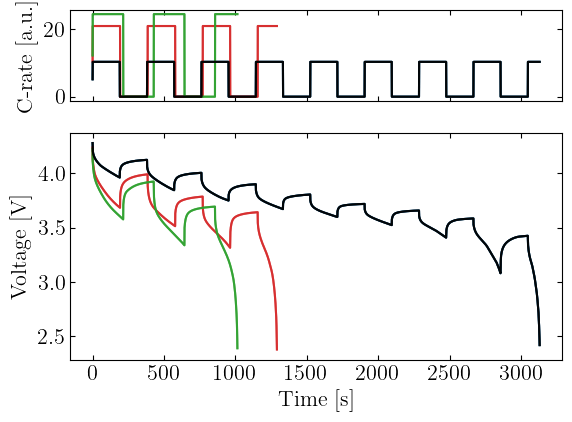

In [9]:
def extract_traj(da, C, u_par):
    # find argmin c-c
    u_C_pairs = da.loc[da['t'] == 0, ['u_par', 'C', 'trajectory']].values
    tr = da[da['trajectory'] == u_C_pairs[int(np.argmin(np.abs((u_C_pairs[:,1] - C)))),2]]
    return tr

f, ax = plt.subplot_mosaic([['current'],['voltage']], figsize=(6, 4.5), height_ratios=[0.4,1], sharex=True)
for j,c in enumerate([2.5,4,5,1]):
    if True:
        df = df_pulse[df_pulse['u_par'] == 0]
    tr = extract_traj(df, C=c, u_par=0.5)
    ax['voltage'].plot(tr['t'], tr['V'], label='CC', color=colors[j], alpha=0.8)
    ax['voltage'].plot(tr['t'], tr['V'], label='Pulse', color=colors[j], alpha=0.8)
    ax['current'].plot(tr['t'], tr['I'], label='CC', color=colors[j], alpha=0.8)
    ax['current'].plot(tr['t'], tr['I'], label='Pulse', color=colors[j], alpha=0.8)
ax['current'].set_ylabel('C-rate [a.u.]')
ax['voltage'].set_ylabel('Voltage [V]')
ax['voltage'].set_xlabel('Time [s]')
fig.legend(ncols = 2, loc='upper center', bbox_to_anchor=(0.5, 1))
plt.tight_layout()


# # f, ax = plt.subplot_mosaic([['current'],['voltage']], figsize=(6, 4.5), height_ratios=[0.4,1], sharex=True)
# # for j,c in enumerate([2,4]):
# #     if True:
# #         df = df_pulse[df_pulse['u_par'] == 0]
# #     tr = extract_traj(df, C=c, u_par=0.5)
# #     ax['voltage'].plot(tr['t'], tr['F'], label='CC', color=colors[j], alpha=0.8)
# #     ax['voltage'].plot(tr['t'], tr['F'], label='Pulse', color=colors[j], alpha=0.8)
# #     ax['current'].plot(tr['t'], tr['u_par'], label='CC', color=colors[j], alpha=0.8)
# #     ax['current'].plot(tr['t'], tr['u_par'], label='Pulse', color=colors[j], alpha=0.8)
# # ax['current'].set_ylabel('C-rate [a.u.]')
# # ax['voltage'].set_ylabel('Voltage [V]')
# # ax['voltage'].set_xlabel('Time [s]')
# # fig.legend(ncols = 2, loc='upper center', bbox_to_anchor=(0.5, 1))
# # plt.tight_layout()


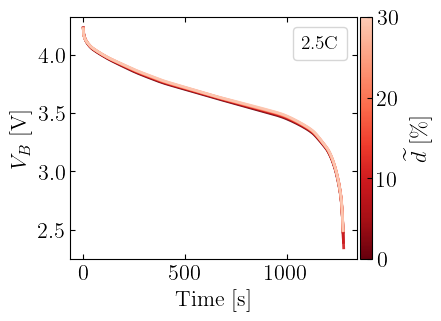

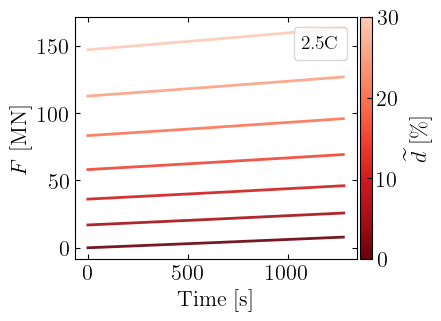

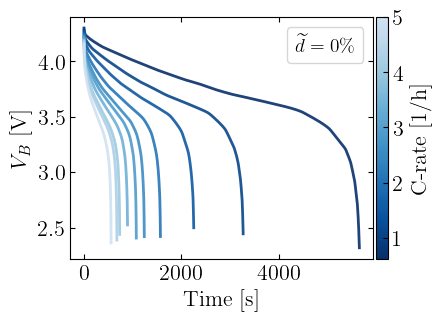

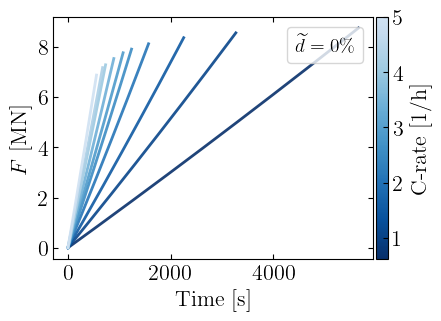

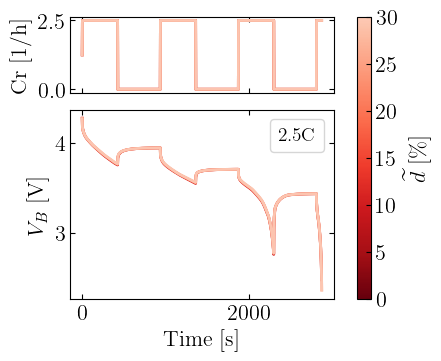

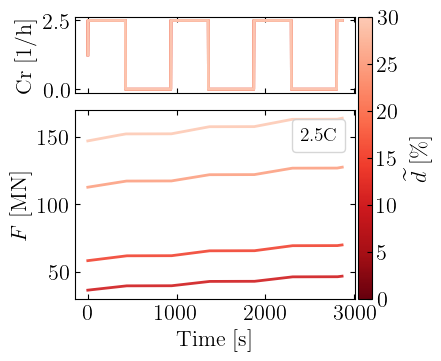

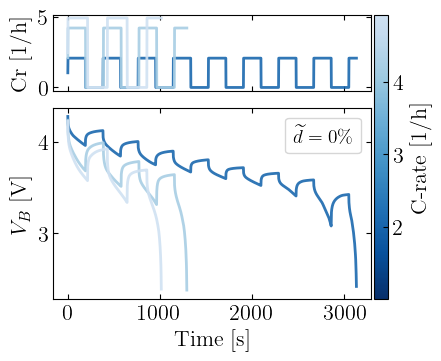

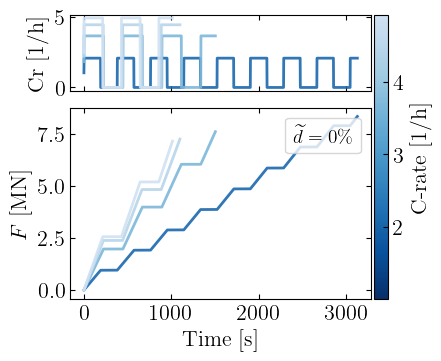

In [21]:
def plot_data_report(trajs, *, sort='C_rate', present='V', n_show=5, pulse=False,
                     Q0=17921.57581):
    """Two-panel (pulse) or single-panel (CC) raw-data plot.
    
    pulse=True  → current panel (top, compact) + voltage panel (bottom),
                  shared colorbar across both.
    pulse=False → voltage panel only, with a fixed-value tag showing the
                  constant of the non-swept variable.
    """
    if sort == 'C_rate':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['C'])
        vals_arr = np.array([tr['C'] for tr in trajs_sorted])
        bar_name = 'C-rate [1/h]'
    elif sort == 'u_per':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['u_per'])
        vals_arr = np.array([tr['u_per'] for tr in trajs_sorted])
        bar_name = r'$\widetilde{d}$ [\%]'
    else:
        raise ValueError(f"sort must be 'C_rate' or 'u_per', got {sort!r}")
    norm = Normalize(vmin=vals_arr.min(), vmax=vals_arr.max())

    if n_show is None or n_show >= len(trajs_sorted):
        trajs_plot = trajs_sorted
    else:
        start = 2 if pulse else 0
        idx = np.unique(np.linspace(start, len(trajs_sorted) - 1, n_show).round().astype(int))
        trajs_plot = [trajs_sorted[i] for i in idx]

    base = plt.cm.Blues_r
    cmap = LinearSegmentedColormap.from_list(
        "Blues_custom", base(np.linspace(0.0, 0.8, 256)))
    base = plt.cm.Reds_r
    cmap_r = LinearSegmentedColormap.from_list(
        "Reds_custom", base(np.linspace(0.0, 0.8, 256)))

    # ── layout ──────────────────────────────────────────────────────────
    if pulse:
        fig, ax = plt.subplot_mosaic(
            [['current'], ['voltage']],
            figsize=(4.3, 3.5),
            height_ratios=[0.4, 1.0],
            sharex=True, constrained_layout=True,
        )
        ax_i, ax_v = ax['current'], ax['voltage']
    else:
        fig, ax_v = plt.subplots(figsize=(4.3, 3.1), constrained_layout=True)
        ax_i = None

    I_to_C = 3600.0 / Q0

    # ── plot ────────────────────────────────────────────────────────────
    for tr in trajs_plot:
        bar_val = float(tr['C']) if sort == 'C_rate' else float(tr['u_per'])
        color = cmap(norm(bar_val)) if sort == 'C_rate' else cmap_r(norm(bar_val))

        t = np.arange(tr['T'])
        V = tr['V'].numpy() if hasattr(tr['V'], 'numpy') else np.asarray(tr['V'])
        F = tr['F'].numpy() if hasattr(tr['F'], 'numpy') else np.asarray(tr['F'])
        if present == 'V':
            ax_v.plot(t, V, color=color, lw=2, alpha=0.9)
        elif present == 'F':
            ax_v.plot(t, F * 1e3, color=color, lw=2, alpha=0.9)

        if pulse and 'I_seq' not in tr:
            raise ValueError(
                "pulse=True but trajectory has no 'I_seq' — did you use prepare_data instead of prepare_pulse_data?")
        if pulse:
            if 'I_seq' in tr:
                I = tr['I_seq'].numpy() if hasattr(tr['I_seq'], 'numpy') else np.asarray(tr['I_seq'])
            else:
                I = tr['I'] * np.ones_like(t)
            ax_i.plot(t, I * I_to_C, color=color, lw=2, alpha=0.9)

    if present == 'V':
        ax_v.set_ylabel(r'$V_B$ [V]')
    elif present == 'F':
        ax_v.set_ylabel(r'$F$ [MN]')
    ax_v.set_xlabel('Time [s]')

    # Fixed-value tag — value of the variable not being swept
    first = trajs_plot[0]
    if sort == 'u_per':
        tag = fr'${float(first["C"]):g}$C'
    else:   # sort == 'C_rate'
        tag = fr'$\widetilde{{d}} = {float(first["u_per"]):g}\%$'

    ax_v.legend(handles=[plt.Line2D([0], [0], color='none', label=tag)], loc='upper right',
                 frameon=True, handlelength=0, handletextpad=0, fontsize=14)
    if pulse:
        ax_i.set_ylabel('Cr [1/h]')
        # ax_v.set_xlim(-100, 3200)
    # else:
    #     ax_v.legend(handles=[plt.Line2D([0], [0], color='none', label=tag)], loc='upper right', frameon=True, handlelength=0, handletextpad=0)
    

    sm = ScalarMappable(cmap=cmap if sort == 'C_rate' else cmap_r, norm=norm)
    sm.set_array([])
    cbar_ax = [ax_i, ax_v] if pulse else ax_v
    fig.colorbar(sm, ax=cbar_ax, label=bar_name, location='right', pad=0.01)
    
    return fig

# ––––––– DC –––––––––––––––––––––––––––––––––––––––––––––––––––––
data_cc = read_data('crate2.5_usweep')
trajs = prepare_data(data_cc)
plot_data_report(trajs, sort='u_per', present='V', n_show=10)
# plt.savefig('xdata_massage_figs/CC_u_sweep_V.pdf', bbox_inches='tight')
plt.show()

plot_data_report(trajs, sort='u_per', present='F', n_show=10)
# plt.savefig('xdata_massage_figs/CC_u_sweep_F.pdf', bbox_inches='tight')
plt.show()

data_cc_old = read_data('polished_DC/merged_DC_hyper')
trajs_d0 = prepare_data(data_cc_old[data_cc_old['u_par'] == 0])
plot_data_report(trajs_d0, sort='C_rate', n_show=10)
plt.savefig('xdata_massage_figs/CC_c_sweep_V.pdf', bbox_inches='tight')
plt.show()

plot_data_report(trajs_d0, sort='C_rate', present='F', n_show=10)
plt.savefig('xdata_massage_figs/CC_c_sweep_F.pdf', bbox_inches='tight')
plt.show()

# # –––––––– Pulse –––––––––––––––––––––––––––––––––––––––––––––––––––
data_pulse = read_data('crate2.5_usweep_pulse')
pulse_trajs = prepare_pulse_data(data_pulse)
plot_data_report(pulse_trajs, sort='u_per', present='V', n_show=4, pulse=True)
plt.savefig('xdata_massage_figs/pulse_u_sweep_V.pdf', bbox_inches='tight')
plt.show()

data_pulse = read_data('crate2.5_usweep_pulse')
pulse_trajs = prepare_pulse_data(data_pulse)
plot_data_report(pulse_trajs, sort='u_per', present='F', n_show=4, pulse=True)
plt.savefig('xdata_massage_figs/pulse_u_sweep_F.pdf', bbox_inches='tight')
plt.show()

data_pulse_old = read_data('combo_half')
pulse_trajs_d0 = prepare_pulse_data(data_pulse_old[(data_pulse_old['u_par'] == 0) & (data_pulse_old['pulse'] == True)])
plot_data_report(pulse_trajs_d0, sort='C_rate', present='V', n_show=3, pulse=True)
plt.savefig('xdata_massage_figs/pulse_c_sweep_V.pdf', bbox_inches='tight')
plt.show()


data_pulse_old = read_data('combo_half')
pulse_trajs_d0 = prepare_pulse_data(data_pulse_old[(data_pulse_old['u_par'] == 0) & (data_pulse_old['pulse'] == True)])
plot_data_report(pulse_trajs_d0, sort='C_rate', present='F', n_show=4, pulse=True)
plt.savefig('xdata_massage_figs/pulse_c_sweep_F.pdf', bbox_inches='tight')
plt.show()

In [11]:
tr = pulse_trajs[0]
print(f"T = {tr['T']}")
print(f"I_seq unique values: {torch.unique(tr['I_seq']).numpy()}")
print(f"I_seq head: {tr['I_seq'].numpy()}")
print(f"I_seq tail: {tr['I_seq'][-10:].numpy()}")
print(f"t monotonic? {bool((tr['t'][1:] > tr['t'][:-1]).all())}")
print(f"t head: {tr['t'][:10].numpy()}, t tail: {tr['t'][-10:].numpy()}")

T = 2865
I_seq unique values: [ 0.         6.2227693 12.4455385]
I_seq head: [ 6.2227693 12.4455385 12.4455385 ... 12.4455385 12.4455385 12.4455385]
I_seq tail: [12.4455385 12.4455385 12.4455385 12.4455385 12.4455385 12.4455385
 12.4455385 12.4455385 12.4455385 12.4455385]
t monotonic? True
t head: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.], t tail: [2855. 2856. 2857. 2858. 2859. 2860. 2861. 2862. 2863. 2864.]


In [12]:
print(tr['I_seq'].numpy())

[ 6.2227693 12.4455385 12.4455385 ... 12.4455385 12.4455385 12.4455385]


In [13]:
def find_duplicate_u_C_pairs(df):
    """
    Find duplicate (u_par, C) pairs in the dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe containing 'u_par' and 'C' columns.

    Returns
    -------
    pd.DataFrame
        Dataframe of duplicate (u_par, C) pairs and their counts.
    """
    duplicates = df.groupby(['u_par', 'C']).size().reset_index(name='count')
    duplicates = duplicates[duplicates['count'] > 1]
    return duplicates

duplicates = find_duplicate_u_C_pairs(u_C_pairs)
print("Duplicate (u_par, C) pairs:")
print(duplicates)

# # remove the duplicates
# for _, row in duplicates.iterrows():
#     u_par = row['u_par']
#     C = row['C']
#     # Find all trajectories with this (u_par, C) pair
#     trajectories_to_remove = data[(data['u_par'] == u_par) & (data['C'] == C)]['trajectory'].unique()
#     # Remove these trajectories from the dataframe
#     data = data[~data['trajectory'].isin(trajectories_to_remove)]

# print("After removing duplicates:")
# duplicates_after = find_duplicate_u_C_pairs(data.loc[data['t'] == 0, ['u_par', 'C']])
# print(duplicates_after)
 

Duplicate (u_par, C) pairs:
Empty DataFrame
Columns: [u_par, C, count]
Index: []


In [14]:
def get_traj_data(trajectory, col,df = data):
    """
    Extract data for a specific trajectory.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing a 'trajectory' column.
    trajectory : int
        The trajectory number to extract.

    Returns
    -------
    pd.DataFrame
        Dataframe containing only the data for the specified trajectory.
    """
    return df[col][df['trajectory'] == trajectory].reset_index(drop=True)

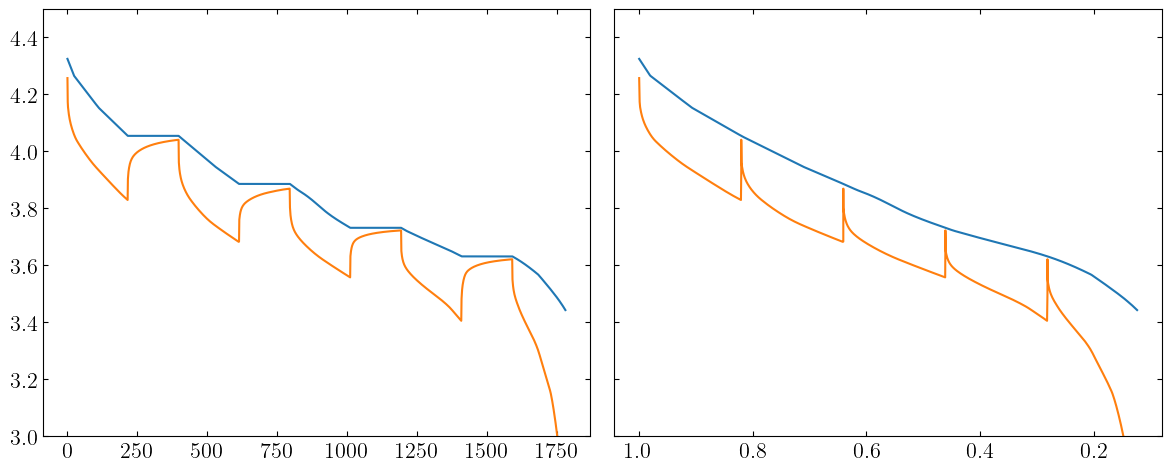

In [15]:
tr_max = 0
f,ax = plt.subplots(1, 2, figsize=(12, 5),sharey=True)
#plt.plot(get_traj_data(data, tr_max, 'soc'))
ax[0].plot(get_traj_data(tr_max,'t',df = data),(get_traj_data(tr_max, 'Ue',df = data)))
ax[0].plot(get_traj_data(tr_max,'t',df = data),get_traj_data(tr_max, 'V',df = data))
ax[1].plot(get_traj_data(tr_max,'soc',df = data),(get_traj_data(tr_max, 'Ue',df = data)))
ax[1].plot(get_traj_data(tr_max,'soc',df = data),get_traj_data(tr_max, 'V',df = data))
ax[1].invert_xaxis()
ax[0].set_ylim(3.0, 4.5)

plt.tight_layout()

In [16]:

start = time.perf_counter()
ocv_sample = GP.soc_to_Ue(data['soc'][data['trajectory'] == tr_max].values,GP_FIT)
end = time.perf_counter()
print(f"GP sampling took {end - start:.4f} seconds for {len(data['soc'][data['trajectory'] == tr_max].values)} points => {len(data['soc'][data['trajectory'] == tr_max].values)**(-1) *1000* (end - start):.3f} ms/point")
plt.plot((data['soc'][data['trajectory'] == tr_max].values), ocv_sample, color = colors[0], label = 'GP regression')
plt.plot(data['soc'][data['trajectory'] == tr_max].values, data['Ue'][data['trajectory'] == tr_max].values, lw = 2, color = 'black', label = 'Data',ls = '--', alpha = 0.5)
plt.xlabel('State of Charge')
plt.gca().invert_xaxis()
plt.ylabel('OCV [V]')
plt.legend()
print(f'MSE: {np.mean((ocv_sample - data["Ue"][data["trajectory"] == tr_max].values)**2):.6e}')

NameError: name 'GP' is not defined

# Plotting data

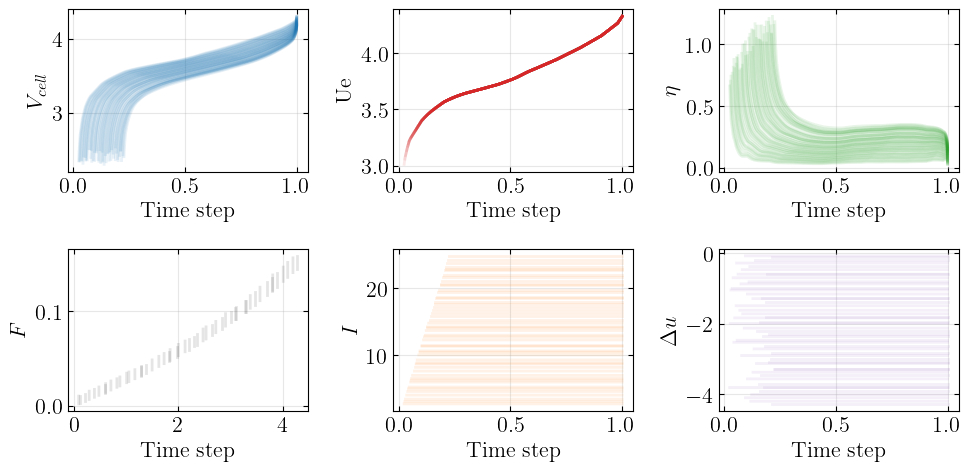

In [ ]:


f, ax = plt.subplots(2, 3, figsize=(10, 5))
for plot_idx in range(data['trajectory'].nunique()):
    for a in ax.flat:
        a.grid(alpha=0.3)
    ax[0,0].plot(data['soc'][data['trajectory'] == plot_idx],data['V'][data['trajectory'] == plot_idx], '-', color = colors[0], lw = 2,alpha = 0.1)
    ax[0,0].set_xlabel('Time step')
    ax[0,0].set_ylabel('$V_{cell}$')
    ax[0,1].plot(data['soc'][data['trajectory'] == plot_idx],data['Ue'][data['trajectory'] == plot_idx], '-', color = colors[1], lw = 2,alpha = 0.1)
    ax[0,1].set_xlabel('Time step')
    ax[0,1].set_ylabel('Ue')
    ax[0,2].plot(data['soc'][data['trajectory'] == plot_idx],data['eta'][data['trajectory'] == plot_idx], '-', color = colors[2], lw = 2,alpha = 0.1)
    ax[0,2].set_xlabel('Time step')
    ax[0,2].set_ylabel(r'$\eta$')
    ax[1,0].plot(-data['u'][data['trajectory'] == plot_idx],data['F'][data['trajectory'] == plot_idx], lw = 2,color = colors[3],alpha = 0.1)
    ax[1,0].set_xlabel('Time step')
    ax[1,0].set_ylabel(r'$F$')
    ax[1,1].plot(data['soc'][data['trajectory'] == plot_idx],data['I'][data['trajectory'] == plot_idx], lw = 2,color = colors[4],alpha = 0.1)
    ax[1,1].set_xlabel('Time step')
    ax[1,1].set_ylabel(r'$I$')
    ax[1,2].plot(data['soc'][data['trajectory'] == plot_idx],data['u'][data['trajectory'] == plot_idx], lw = 2,color = colors[5],alpha = 0.1)
    ax[1,2].set_xlabel('Time step')
    ax[1,2].set_ylabel(r'$\Delta u$')
    

plt.tight_layout()

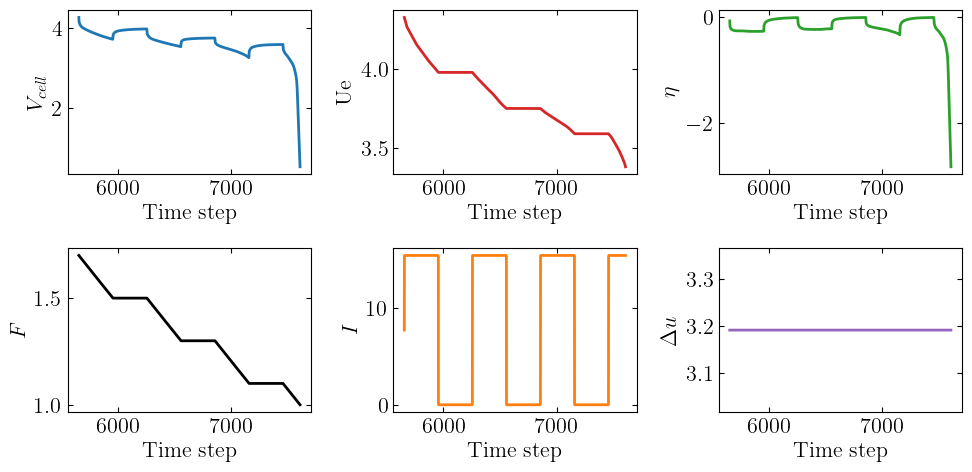

In [ ]:
plot_idx = data_pulse['trajectory'] == 3
f, ax = plt.subplots(2, 3, figsize=(10, 5))
ax[0,0].plot(data_pulse['V'][plot_idx], '-', color = colors[0], lw = 2)
ax[0,0].set_xlabel('Time step')
ax[0,0].set_ylabel('$V_{cell}$')
ax[0,1].plot(data_pulse['Ue'][plot_idx], '-', color = colors[1], lw = 2)
ax[0,1].set_xlabel('Time step')
ax[0,1].set_ylabel('Ue')
ax[0,2].plot(data_pulse['eta'][plot_idx], '-', color = colors[2], lw = 2)
ax[0,2].set_xlabel('Time step')
ax[0,2].set_ylabel(r'$\eta$')
ax[1,0].plot(data_pulse['F'][plot_idx], lw = 2,color = colors[3])
ax[1,0].set_xlabel('Time step')
ax[1,0].set_ylabel(r'$F$')
ax[1,1].plot(data_pulse['I'][plot_idx], lw = 2,color = colors[4])
ax[1,1].set_xlabel('Time step')
ax[1,1].set_ylabel(r'$I$')
ax[1,2].plot(data_pulse['u'][plot_idx], lw = 2,color = colors[5])
ax[1,2].set_xlabel('Time step')
ax[1,2].set_ylabel(r'$\Delta u$')

plt.tight_layout()
plt.show()

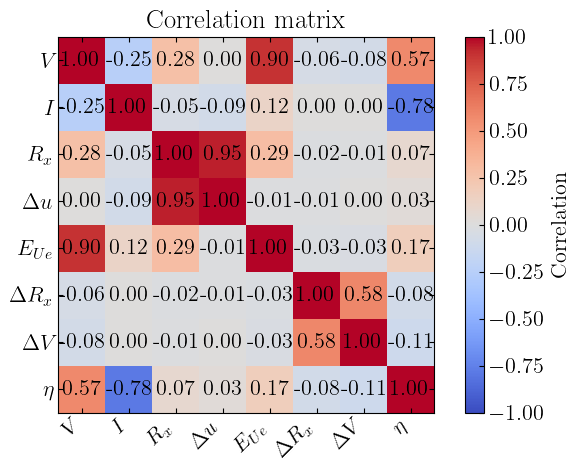

In [ ]:
# Correlation matrix for current signals in this batch

X = data[['V','I','F','u_par','Ue','dF','dV','eta']].values
feature_names = ['$V$','$I$','$R_x$',r'$\Delta u$','$E_{Ue}$',r'$\Delta R_x$',r'$\Delta V$',r'$\eta$']
with np.errstate(invalid="ignore", divide="ignore"):
    corr = np.corrcoef(X, rowvar=False)


fig, ax_corr = plt.subplots(figsize=(7, 5))
im = ax_corr.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax_corr.set_xticks(np.arange(len(feature_names)))
ax_corr.set_yticks(np.arange(len(feature_names)))
ax_corr.set_xticklabels(feature_names, rotation=45, ha="right")
ax_corr.set_yticklabels(feature_names)
ax_corr.set_title("Correlation matrix")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax_corr, label="Correlation")
plt.tight_layout()
plt.show()

53.164 GN/mm


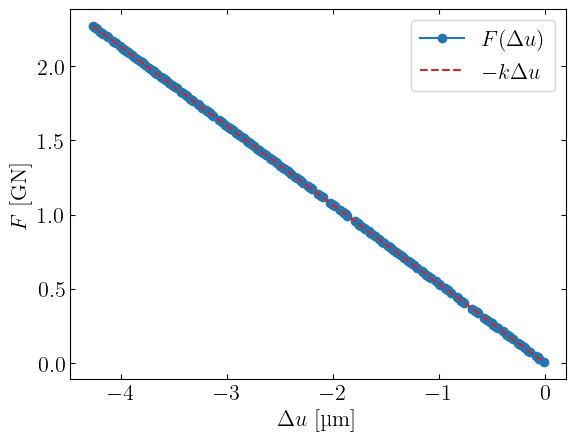

In [ ]:
traj = 0
#plt.plot(data['u'][data['trajectory'] == traj], data['F'][data['trajectory'] == traj], lw = 2, color = colors[0])
groups = data.groupby('u')['F']


first_F = data.groupby('u')['F'].first()
k = abs(first_F / (data.groupby('u')['u'].first()))
plt.plot(data.groupby('u')['u'].first(), first_F, 'o-', color = colors[0], label = r'$F(\Delta u)$')
plt.plot(data.groupby('u')['u'].first(), -k * data.groupby('u')['u'].first(), '--', color = colors[1], label = r'$-k\Delta u$')
plt.xlabel(r'$\Delta u$ [µm]')
plt.ylabel(r'$F$ [GN]')
plt.legend()
print(f'{100 * k.values[0]:.3f} GN/mm')


Text(0, 0.5, '$F$ [MN]')

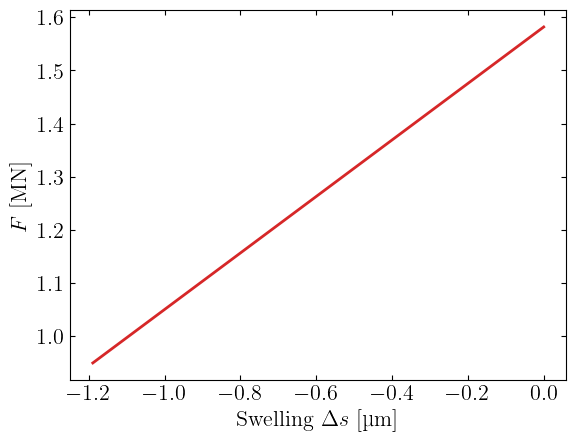

In [ ]:
traj = 1

ds = data['F'][data['trajectory'] == traj] / k.values[0] + data['u'][data['trajectory'] == traj] 

plt.plot(ds,data['F'][data['trajectory'] == traj], lw = 2, color = colors[1])
plt.xlabel(r'Swelling $\Delta s$ [µm]')
plt.ylabel(r'$F$ [MN]')

# Normalizing data

### Characteristics that should be preserved after normalization?


- $\Delta u$: It should primarily be compression, so have a negative sign. 
    - $\Delta u / L$ gives a fractional compression 
- $I$: The sign of it should reflect if we have charge/discharge
    - Maybe just a `standard` normalization on this? 
- $V$: It should always be positive
    - Maybe just a `min-max` normalization on this? 
- $F$: The sign of it should in some way reflect the sign of $\Delta u$. Especially in the cases with low swelling. 
    - Maybe just a `standard` normalization on this? 

In [ ]:
N_trajs = len(data['trajectory'].unique())


X = data[['I','u','soc','Ue','trajectory']].values
y = data[['V','F','trajectory']].values

In [ ]:
N_trajs = len(data['trajectory'].unique())

x_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

split = (data['trajectory']<=int(N_trajs *0.8)).sum()

def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

x_train, x_test = _split_flat(x_tensor); y_train, y_test = _split_flat(y_tensor)

print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')

print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')

Number of trajectories in train: 198 out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([334590, 5])	y-train shape: torch.Size([334590, 3])
X-test shape: torch.Size([80967, 5])	y-test shape: torch.Size([80967, 3])


In [ ]:
def _split_flat(arr, split = split):
    return arr[:split], arr[split:]   # Same as reshape(B * T, C)    # (B*T, 4)

def get_train_test(df):
    N_trajs = len(df['trajectory'].unique())
    x_tensor = torch.tensor(df[['I','u','soc','Ue','trajectory']].values, dtype=torch.float32)
    y_tensor = torch.tensor(df[['V','F','trajectory']].values, dtype=torch.float32)
    split = (df['trajectory']<=int(N_trajs *0.8)).sum()
    x_train, x_test = _split_flat(x_tensor, split); y_train, y_test = _split_flat(y_tensor, split)
    print(f'Number of trajectories in train: {int(N_trajs * 0.8)} out of {N_trajs}')
    print(f'X shape {x_tensor.shape}\ty shape {y_tensor.shape}\nX-train shape: {x_train.shape}\ty-train shape: {y_train.shape}\nX-test shape: {x_test.shape}\ty-test shape: {y_test.shape}')
    return x_train, y_train, x_test, y_test

In [ ]:
x_train, y_train, x_test, y_test = get_train_test(data)
x_train_pulse, y_train_pulse, x_test_pulse, y_test_pulse = get_train_test(data_pulse)

Number of trajectories in train: 198 out of 248
X shape torch.Size([415557, 5])	y shape torch.Size([415557, 3])
X-train shape: torch.Size([334590, 5])	y-train shape: torch.Size([334590, 3])
X-test shape: torch.Size([80967, 5])	y-test shape: torch.Size([80967, 3])
Number of trajectories in train: 40 out of 50
X shape torch.Size([126623, 5])	y shape torch.Size([126623, 3])
X-train shape: torch.Size([99530, 5])	y-train shape: torch.Size([99530, 3])
X-test shape: torch.Size([27093, 5])	y-test shape: torch.Size([27093, 3])


In [ ]:
import torch.nn.functional as TF

''' R1 '''

def ECM_model(Ue, I, R0, U1):
    #Ue = soc_to_Ue(soc,return_torch=True    )
    return Ue - I * R0 - U1

def Mech_model(u,Fs , k = k.values[0]):
    return -k * u + Fs

def soc_force_func(soc, variable = 'F'):
    
    if variable == 'F': 
        forcing_const = 0.9975
    elif variable == 'U':
        forcing_const = 0.995
    return 1 - np.exp((soc-1) / (1 - forcing_const));

def R0_func(I,u):
    x0 = u
    x1 = I
    return x0*(-0.0001887521) - 7.049519e-5*x1 + 0.00844669;



class R1Net(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(R1Net, self).__init__()
        self.Snet = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if False:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:
            Fs_raw, R1_raw = self.Snet(x)[:,0], self.Snet(x)[:,1]
            soc = x[:,2]
            Fs = soc_force_func(soc) * Fs_raw
            R1 = TF.softplus(R1_raw) / 100  # Ensure R1 is non-negative

            return Fs, R1

modelR1 = R1Net()
optimizerR1 = optim.Adam(modelR1.parameters(), lr=1e-3)  

In [ ]:
class C1Net(nn.Module):
    def __init__(self, input_size=3, hidden_size=256): 
        super(C1Net, self).__init__()
        self.Cnet = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)   # output size is 2 for (V_cell, F)
        )

    def forward(self, x):
        
        if False:
            Fs_raw = self.net(x)[:,0] #* force_func(soc)  # (T,)
            U1_raw = self.net(x)[:,1] 
            soc = x[:,2]
            Fs = soc_force_func(soc, variable='F') * Fs_raw;
            U1 = soc_force_func(soc, variable = 'U') * TF.softplus(U1_raw);
            
            return Fs, U1
        else:

            C_min = 1000
            C_max = 2e4
            C1_raw = self.Cnet(x)[:,0]

            C1 = C_min + TF.sigmoid(C1_raw) * (C_max - C_min) # Ensure R1 is non-negative and bounded between C_min and C_max

            return C1
        
modelC1 = C1Net()
optimizerC1 = optim.Adam(modelC1.parameters(), lr=1e-3)  

In [ ]:
def model(I,u,soc,Ue,case):
    R0 = R0_func(I,u)
    if case == 'R1':
        x = torch.stack((I,u,soc), dim=1)
        Fs, R1 = modelR1(x)
        U1 = R1 * I
    elif case == 'C1':
        U1 = torch.zeros_like(I)
        for t in range(1,len(I)):
            x = torch.tensor([I[t],u[t],soc[t]], dtype=torch.float32).unsqueeze(0)  # (1, 3)
            C1 = modelC1(x)  # (1,)
            R1 = modelR1(x)[1]  # (1,)
            U1[t] = U1[t-1] * (1 - 1 / (R1 * C1)) + I[t] / C1
    return torch.stack([ECM_model(Ue, I, R0, U1),Mech_model(u, Fs)], dim=1) 

In [ ]:
def get_NN_model(case):
    if case == 'R1':
        return modelR1
    elif case == 'C1':
        return modelC1
    else:
        raise ValueError(f"Unknown case: {case}. Valid cases are 'R1' and 'C1'.")

In [ ]:
try: 
    print(summary(modelR1, input_data=x_train[:2]))
except Exception as e:
    print(f"Error in model summary: {e}")

Error in model summary: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: []


In [ ]:
def training(epochs=30, case='R1'):
    history = {"loss": [], "V_loss": [], "F_loss": [], "time per ep": []}

    NN_model.train()
    tot_time = 0.
    MAX_TIME_min = 3.5
    for ep in range(epochs):
        start_t = time.perf_counter()    
        ep_loss = 0.0

        for traj in range(int(N_trajs * 0.8)):

            x_traj = x_train[x_train[:, -1] == traj]
            y_traj = y_train[y_train[:, -1] == traj]

            # Inputs
            model_input = x_traj[:, :-1]      # (T, 3)
            model_target = y_traj[:,:-1]     # (T, 2)

            I   = model_input[:, 0]
            u   = model_input[:, 1]
            soc = model_input[:, 2]
            Ue  = model_input[:, 3]
            
            #Ue = soc_to_Ue(soc, return_torch=True)  # (T,)      

            # Forward
            y_pred = model(I,u,soc,Ue, case = case)                # (T, 2)

            V_loss = nn.MSELoss()(y_pred[:,0], model_target[:,0])
            F_loss = nn.MSELoss()(y_pred[:,1], model_target[:,1])
            #U_1_curve_loss = ((U1[2:] - 2*U1[1:-1] + U1[:-2])**2).mean()
            loss = V_loss + F_loss #+ 1e-2 * U_1_curve_loss
            #print(f'Traj {traj} | loss {loss.item():.2e} | V_loss {V_loss.item():.2e} | F_loss {F_loss.item():.2e} | U1_curve_loss {U_1_curve_loss.item():.2e}')
            # Backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            ep_loss += loss.item()
            print(ep_loss)
        #print(f"Epoch {ep+1}/{epochs} | loss {ep_loss:.2e} | V_loss {V_loss.item():.2e} | F_loss {F_loss.item():.2e} | time {(time.perf_counter() - start_t):.2f}s")
        ep_loss /= N_trajs

        history["loss"].append(ep_loss)
        history["V_loss"].append(V_loss.item() / N_trajs)
        history["F_loss"].append(F_loss.item() / N_trajs)
        end_t = time.perf_counter()
        history["time per ep"].append(end_t - start_t)   
        
        tot_time += end_t - start_t
       
        if ep == 0:
            print(f'ETA: {(end_t - start_t) * epochs / 60:.2f} min')

        if tot_time > MAX_TIME_min*60:
            print(f"Early stopping: Total training time exceeded {MAX_TIME_min} minutes.")
            break
        print(f"Epoch {ep+1} | loss {ep_loss:.2e} | V_loss {V_loss.item():.2e} | F_loss {F_loss.item():.2e} | time {end_t - start_t:.2f}s")

    return history      

In [ ]:
history = training(epochs=500)

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_29960/3197020153.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(250*(soc - 1))


ETA: 7.45 min
Epoch 1 | loss 1.77e-01 | V_loss 2.66e+01 | F_loss 5.23e-02 | time 0.89s
Epoch 2 | loss 5.87e-03 | V_loss 8.37e-01 | F_loss 4.33e-02 | time 0.94s
Epoch 3 | loss 3.28e-04 | V_loss 8.54e-03 | F_loss 4.07e-02 | time 0.97s
Epoch 4 | loss 3.19e-04 | V_loss 1.12e-02 | F_loss 3.66e-02 | time 0.81s
Epoch 5 | loss 4.52e-04 | V_loss 3.62e-02 | F_loss 3.15e-02 | time 0.90s
Epoch 6 | loss 3.46e-04 | V_loss 2.54e-02 | F_loss 2.66e-02 | time 0.83s
Epoch 7 | loss 3.47e-04 | V_loss 3.16e-02 | F_loss 2.05e-02 | time 0.84s
Epoch 8 | loss 1.28e-04 | V_loss 5.80e-03 | F_loss 1.34e-02 | time 0.85s
Epoch 9 | loss 1.93e-03 | V_loss 2.84e-01 | F_loss 5.27e-03 | time 0.76s
Epoch 10 | loss 8.00e-03 | V_loss 1.19e+00 | F_loss 4.97e-03 | time 0.77s
Epoch 11 | loss 3.99e-02 | V_loss 5.97e+00 | F_loss 8.59e-03 | time 0.82s
Epoch 12 | loss 9.91e-04 | V_loss 1.45e-01 | F_loss 3.49e-03 | time 0.99s
Epoch 13 | loss 2.73e-02 | V_loss 4.09e+00 | F_loss 1.70e-03 | time 0.98s
Epoch 14 | loss 8.44e-04 | V_loss

1.4191573796172935e-05


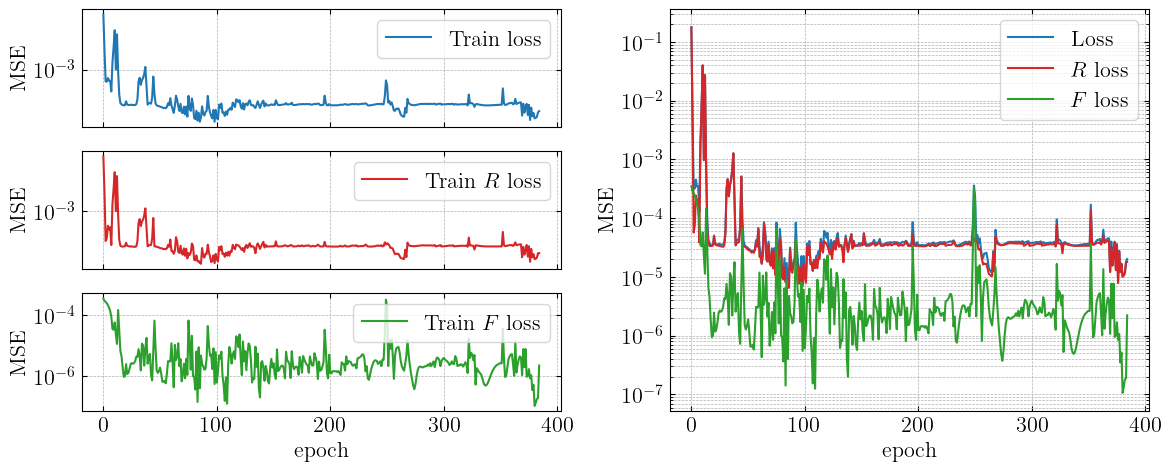

In [ ]:
print(np.mean(history['loss'][-5:]))

fig, ax = plt.subplot_mosaic(
    [
        ["loss", "combined"],
        ["V_loss", "combined"],
        ["F_loss", "combined"]
    ],
    figsize=(12, 5),
    sharex=True
)

# Individual plots
ax["loss"].semilogy(history["loss"], label="Train loss", color=colors[0])
ax["V_loss"].semilogy(history["V_loss"], label=r"Train $R$ loss", color=colors[1])
ax["F_loss"].semilogy(history["F_loss"], label=r"Train $F$ loss", color=colors[2])

# Combined plot (all together)
ax["combined"].semilogy(history["loss"], label="Loss", color=colors[0])
ax["combined"].semilogy(history["V_loss"], label=r"$R$ loss", color=colors[1])
ax["combined"].semilogy(history["F_loss"], label=r"$F$ loss", color=colors[2])

# Labels and styling
ax["F_loss"].set_xlabel("epoch")
ax["combined"].set_xlabel("epoch")

for key in ["loss", "V_loss", "F_loss", "combined"]:
    ax[key].set_ylabel("MSE")
    ax[key].legend()
    ax[key].grid(True, which="both", ls="--", lw=0.5)

plt.tight_layout()
plt.show()

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_29960/3197020153.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(250*(soc - 1))


KeyError: 'soc'

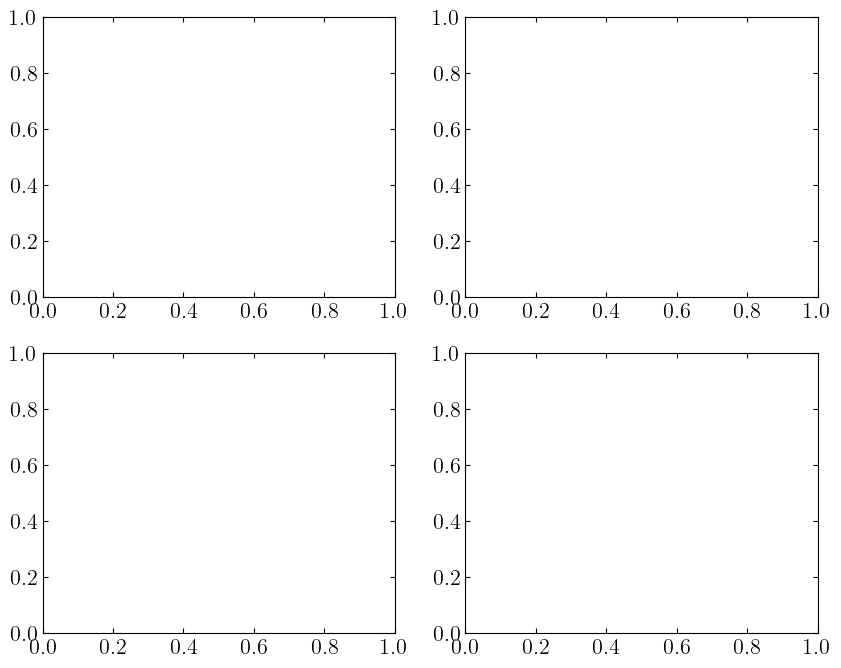

In [ ]:
def evaluate(model, x_test, y_test):
    model.eval()
    with torch.no_grad():
        I = x_test[:,0]
        u = x_test[:,1]
        Ue = x_test[:,2]

        R0_pred, F_pred = model(x_test)
        y_pred = torch.stack([ECM_box(Ue,I,R0_pred), Mech_box(u,F_pred)],dim=1)

        #test_loss = nn.MSELoss()(y_pred, y_test).item()
    #print(f"Test MSE: {test_loss:.3e}")
    return y_pred.detach().numpy(), R0_pred.detach().numpy(), F_pred.detach().numpy()   


traj_eval = 0
y_pred, R0, F = evaluate(model, x_train[x_train[:,-1] == traj_eval][:,:-1], y_train[y_train[:,2] == traj_eval][:,:-1])


f, ax = plt.subplots(2, 2, figsize=(10, 8))
#plt.plot(x_test[:,0].numpy()* R0.detach().numpy(), label='Predicted $R_0$')
ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values, R0, label=r'Predicted $IR_0$',color = colors[0])
ax[0,0].plot(data['soc'][data['trajectory'] == traj_eval].values,-data['eta'][data['trajectory'] == traj_eval].values / x_train[x_train[:,-1] == traj_eval][:,0].numpy(), label=r'True $\eta$',color = colors[1],ls = '--')

ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['V_t'][data['trajectory'] == traj_eval].values, label=r'True $V_t$', color = colors[1],ls = '--')
ax[0,1].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,0], label=r'Predicted $V_t$', color = colors[0])

ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,data['Rx'][data['trajectory'] == traj_eval].values, label=r'True $F$', color = colors[1],ls = '--')
ax[1,0].plot(data['soc'][data['trajectory'] == traj_eval].values,y_pred[:,1], label=r'Predicted $F$', color = colors[0])    

ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,data['Rx'][data['trajectory'] == traj_eval].values + k.values[0] * x_train[x_train[:,-1] == traj_eval][:,1].numpy(), label=r'True $F_s$', color = colors[1], ls = '--')
ax[1,1].plot(data['soc'][data['trajectory'] == traj_eval].values,F, label=r'Pred $F_s$', color = colors[0])

for a in ax.flat:
    a.set_xlabel('State of Charge')
    a.legend()
    a.invert_xaxis()
ax[0,0].set_ylabel(r'$\eta$ and $IR_0$')
ax[0,1].set_ylabel(r'$V_t$ [V]')
ax[1,0].set_ylabel(r'$F$ [GN]')
ax[1,1].set_ylabel(r'$-k\Delta u$ [GN]')
plt.tight_layout()

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_29960/3197020153.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 - np.exp(250*(soc - 1))


Test MSE: [2.997e-03,1.742e-04], RMSE: [5.475e-02,1.320e-02], MAE: [3.560e-02,1.260e-02], R2: [0.961,0.996]
Test MSE: [3.128e-03,1.720e-04], RMSE: [5.593e-02,1.311e-02], MAE: [3.581e-02,1.244e-02], R2: [0.959,0.996]
Test MSE: [2.460e-03,2.242e-04], RMSE: [4.959e-02,1.497e-02], MAE: [3.237e-02,1.449e-02], R2: [0.966,0.994]
Test MSE: [7.247e-03,3.670e-04], RMSE: [8.513e-02,1.916e-02], MAE: [4.569e-02,1.882e-02], R2: [0.902,0.989]
Test MSE: [1.632e-03,1.284e-04], RMSE: [4.040e-02,1.133e-02], MAE: [2.134e-02,1.109e-02], R2: [0.979,0.997]
Test MSE: [4.544e-03,2.556e-04], RMSE: [6.741e-02,1.599e-02], MAE: [4.501e-02,1.576e-02], R2: [0.939,0.993]
Test MSE: [2.344e-03,1.088e-04], RMSE: [4.841e-02,1.043e-02], MAE: [2.983e-02,1.005e-02], R2: [0.968,0.997]
Test MSE: [9.064e-03,6.240e-04], RMSE: [9.521e-02,2.498e-02], MAE: [6.498e-02,2.488e-02], R2: [0.882,0.979]
Test MSE: [4.637e-03,2.223e-04], RMSE: [6.810e-02,1.491e-02], MAE: [3.972e-02,1.466e-02], R2: [0.936,0.994]
Test MSE: [1.680e-03,5.945e-

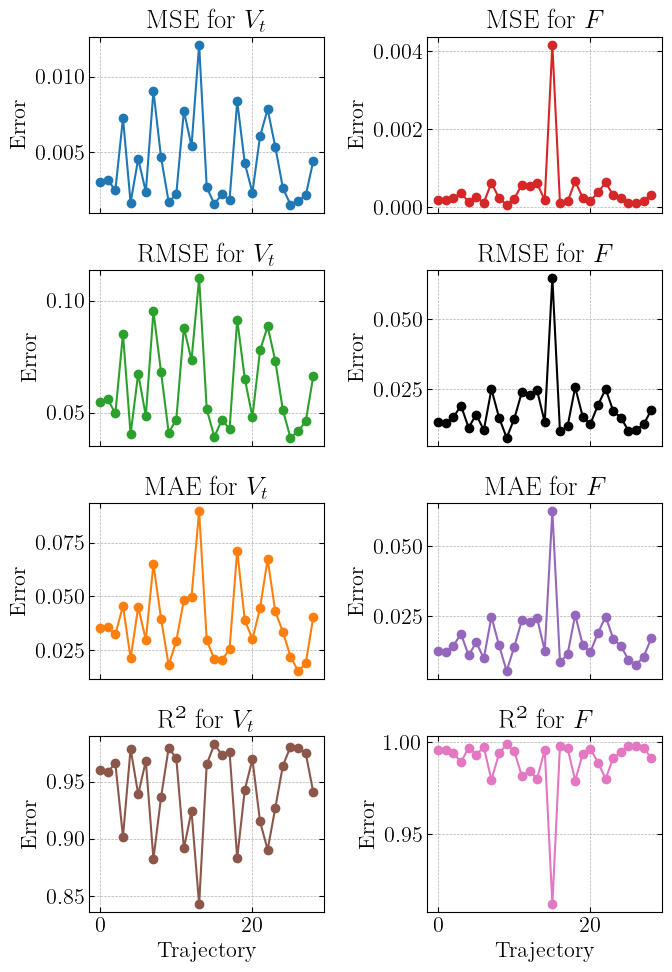

In [ ]:
def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)
    return mse, rmse, mae, r2


def evaluate_metrics(model, x, y):
    model.eval()
    mse = np.zeros((torch.unique(x[:, -1]).numel(),2))
    rmse = np.zeros_like(mse)
    mae = np.zeros_like(mse)
    r2 = np.zeros_like(mse)
    j = 0
    for traj in x[:,-1].unique():
        x_traj = x[x[:,-1] == traj][:,:-1]
        y_traj = y[y[:,-1] == traj][:,:-1]
        with torch.no_grad():
            I = x_traj[:,0]
            u = x_traj[:,1]
            Ue = x_traj[:,2]

            R0_pred, F_pred = model(x_traj)
            y_pred = torch.stack([ECM_box(Ue,I,R0_pred), Mech_box(u,F_pred)],dim=1)

        y_true = y_traj.numpy()
        y_pred_np = y_pred.numpy()

        mse[j,0], rmse[j,0], mae[j,0], r2[j,0] = metrics(y_true[:,0], y_pred_np[:,0])
        mse[j,1], rmse[j,1], mae[j,1], r2[j,1] = metrics(y_true[:,1], y_pred_np[:,1])
        print(f"Test MSE: [{mse[j,0]:.3e},{mse[j,1]:.3e}], RMSE: [{rmse[j,0]:.3e},{rmse[j,1]:.3e}], MAE: [{mae[j,0]:.3e},{mae[j,1]:.3e}], R2: [{r2[j,0]:.3f},{r2[j,1]:.3f}]")
        j += 1
    return mse, rmse, mae, r2

mse, rmse, mae, r2 = evaluate_metrics(model, x_test, y_test)

f, ax = plt.subplots(4, 2, figsize=(7, 10),sharex=True)

ax[0,0].plot(mse[:,0], 'o-', color = colors[0])
ax[0,1].plot(mse[:,1], 'o-', color = colors[1])
ax[1,0].plot(rmse[:,0], 'o-', color = colors[2])
ax[1,1].plot(rmse[:,1], 'o-', color = colors[3])
ax[2,0].plot(mae[:,0], 'o-', color = colors[4])
ax[2,1].plot(mae[:,1], 'o-', color = colors[5])
ax[3,0].plot(r2[:,0], 'o-', color = colors[6])
ax[3,1].plot(r2[:,1], 'o-', color = colors[7])

ax[0,0].set_title('MSE for $V_t$')
ax[0,1].set_title('MSE for $F$')    
ax[1,0].set_title('RMSE for $V_t$')
ax[1,1].set_title('RMSE for $F$')
ax[2,0].set_title('MAE for $V_t$')
ax[2,1].set_title('MAE for $F$')
ax[3,0].set_title('R² for $V_t$')
ax[3,1].set_title('R² for $F$')
ax[3,0].set_xlabel('Trajectory')
ax[3,1].set_xlabel('Trajectory')
for a in ax.flat:
    a.set_ylabel('Error')
    a.grid(True, ls='--', lw=0.5)
plt.tight_layout()
plt.show()
